# M2: Morgan Fingerprint Baseline

Goal: build the first ML baseline for EGFR pIC50 prediction.

```text
canonical_smiles -> RDKit Mol -> Morgan fingerprint
                 -> RandomForest / XGBoost -> pIC50
```

This notebook uses the **already processed** M1 dataset and does not
repeat ChEMBL download or preprocessing.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from scipy.stats import pearsonr, spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# Locate the project root whether jupyter starts from the root or notebooks/
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Load the M1 dataset

Each row is one unique standardized molecule. `pIC50` is the median
of repeated exact IC50 measurements converted with
`pIC50 = 9 - log10(IC50_nM)`.

In [2]:
final_df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "egfr_activity_final.csv")
print(f"molecules: {len(final_df):,}")
print(f"pIC50 range: {final_df['pIC50'].min():.2f} - {final_df['pIC50'].max():.2f}")
final_df.head()

molecules: 10,161
pIC50 range: 1.60 - 11.52


,canonical_smiles,pIC50,IC50_nM,activity_class,n_measurements,pIC50_std,pIC50_min,pIC50_max,molecule_chembl_id,molecule_chembl_ids,n_molecules
0,Brc1cc2c(NCc3ccccc3)ncnc2s1,6.617983,241.0,0,1,NaN,6.617983,6.617983,CHEMBL3416599,CHEMBL3416599,1
1,Brc1cc2c(NCc3ccccn3)ncnc2s1,5.102153,7904.0,0,1,NaN,5.102153,5.102153,CHEMBL3416616,CHEMBL3416616,1
2,Brc1cc2c(NCc3cccs3)ncnc2s1,5.862013,1374.0,0,1,NaN,5.862013,5.862013,CHEMBL3416619,CHEMBL3416619,1
3,Brc1cc2c(NCc3ccncc3)ncnc2s1,5.410833,3883.0,0,1,NaN,5.410833,5.410833,CHEMBL3416614,CHEMBL3416614,1
4,Brc1cc2c(Nc3ccccc3)ncnc2s1,7.096910,80.0,1,1,NaN,7.096910,7.096910,CHEMBL3416621,CHEMBL3416621,1


## 2. SMILES -> RDKit Mol -> Morgan fingerprint

`Chem.MolFromSmiles` parses the string into an RDKit Mol object.
`AllChem.GetMorganGenerator(radius=2, fpSize=2048).GetFingerprint(mol)` then
turns the
molecule into a fixed-length 0/1 vector. Each bit represents whether a
particular circular chemical environment exists in the molecule.

In [3]:
def smiles_to_fp(smiles: str, radius: int = 2, n_bits: int = 2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    generator = AllChem.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp = generator.GetFingerprint(mol)
    return np.array(list(fp), dtype=np.float32)

X = np.vstack(final_df["canonical_smiles"].map(smiles_to_fp).to_numpy())
y = final_df["pIC50"].to_numpy(dtype=np.float32)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (10161, 2048)
y shape: (10161,)


## 3. Random train/test split

M2 uses a random split so the two models can be compared under the
same conditions. M3 will replace this with a scaffold split, which is
a harder and more realistic test.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"train: {len(y_train):,}   test: {len(y_test):,}")

train: 8,128   test: 2,033


## 4. Train RandomForest and XGBoost

RandomForest averages many decision trees; XGBoost builds trees
sequentially, each one correcting the previous errors. Both accept the
fingerprint matrix directly.

In [5]:
models = {
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1, verbosity=0),
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
print("training done")

training done


## 5. Evaluate on the held-out test set

Metrics:
- `RMSE` / `MAE`: prediction error in pIC50 units;
- `R2`: fraction of variance explained;
- `Pearson r`: linear correlation between observed and predicted;
- `Spearman rho`: rank correlation (more robust to outliers).

In [6]:
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
        "Pearson_r": pearsonr(y_true, y_pred)[0],
        "Spearman_rho": spearmanr(y_true, y_pred)[0],
    }

metrics = {}
predictions = {}
for name, model in trained.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    metrics[name] = evaluate(y_test, y_pred)
    print(f"\n{name}:")
    for k, v in metrics[name].items():
        print(f"  {k}: {v:.4f}")


RandomForest:
  MAE: 0.5361
  RMSE: 0.7379
  R2: 0.7010
  Pearson_r: 0.8378
  Spearman_rho: 0.8370

XGBoost:
  MAE: 0.6236
  RMSE: 0.8163
  R2: 0.6340
  Pearson_r: 0.7987
  Spearman_rho: 0.8027


In [7]:
saved_path = RESULTS_DIR / "m2_morgan_baseline_results.json"
if saved_path.exists():
    saved = json.loads(saved_path.read_text())
    match = saved["metrics"] == metrics
    print("notebook metrics match saved JSON:", match)
    if not match:
        raise ValueError("Notebook metrics differ from src/models/morgan_baseline.py JSON")
else:
    print("saved JSON not found; run src/models/morgan_baseline.py first")

notebook metrics match saved JSON: True


## 6. Predicted vs observed plot

Points should lie near the red diagonal. Systematic deviation above or
below the line means the model is biased (e.g. it underestimates potent
compounds or overestimates weak ones).

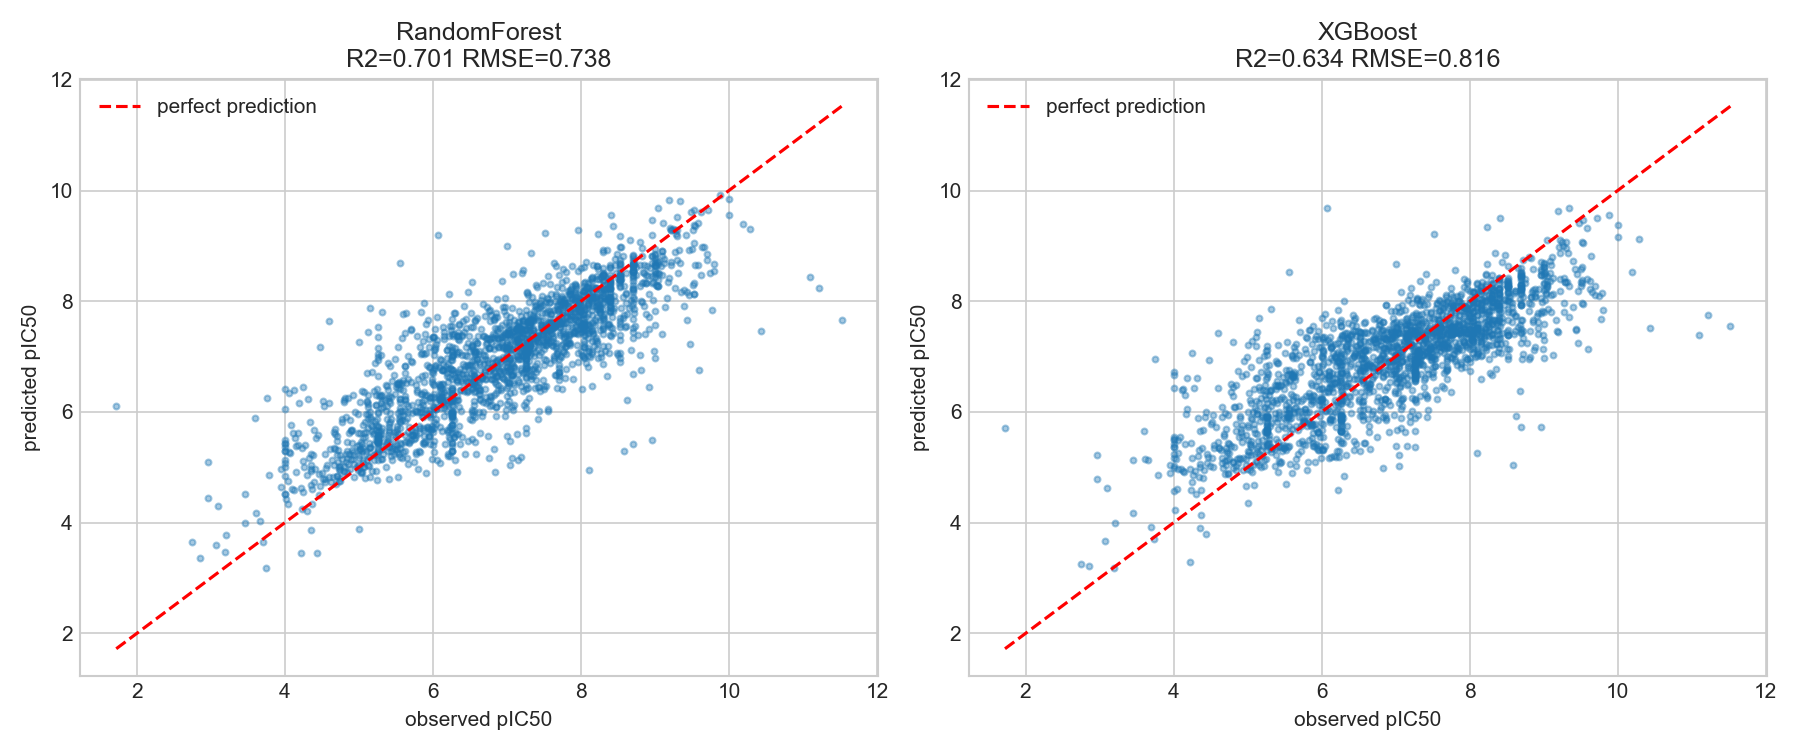

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, s=8, alpha=0.4)
    lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lim, lim, "r--", label="perfect prediction")
    ax.set_xlabel("observed pIC50")
    ax.set_ylabel("predicted pIC50")
    ax.set_title(f"{name}\nR2={metrics[name]['R2']:.3f} RMSE={metrics[name]['RMSE']:.3f}")
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "m2_morgan_baseline_predicted_vs_actual.png", dpi=150)
plt.show()

## 7. How to interpret the results

1. A reasonable random-split baseline on this type of dataset often has
   R2 around 0.4-0.7 and RMSE around 1.0-1.3 pIC50 units. Do not expect
   near-perfect performance: IC50 measurements are noisy and the dataset
   is aggregated across many assays.
2. Random split is optimistic because similar molecules appear in both
   train and test. M3's scaffold split will tell us how well the model
   generalizes to new chemical scaffolds.
3. Keep this baseline as the reference: M4 (GNN) and M5 (Transformer)
   should beat it to justify the extra complexity.